## RandomForest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/전처리완료.csv")

In [2]:
# 데이터 분리 라이브러리
from sklearn.model_selection import train_test_split

# 특징 변수(X)와 목표 변수(y) 분리
X = df.drop('고객이탈여부', axis=1)
y = df['고객이탈여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# 라이브러리 불러오기
from sklearn.ensemble import RandomForestClassifier

# 로지스틱 회귀 모델 학습
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 예측
y_pred = rf.predict(X_test)

y_pred

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

In [4]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8645
Precision: 0.75
Recall 0.46564885496183206
f1_score 0.5745682888540031
Confusion Matrix:
 [[1546   61]
 [ 210  183]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



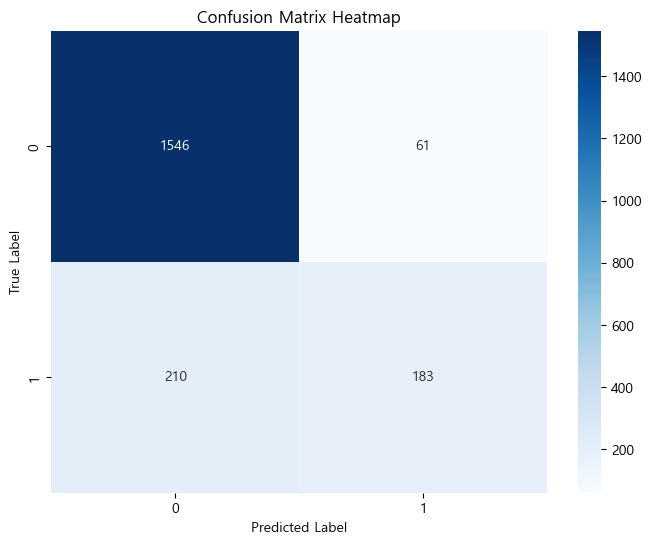

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

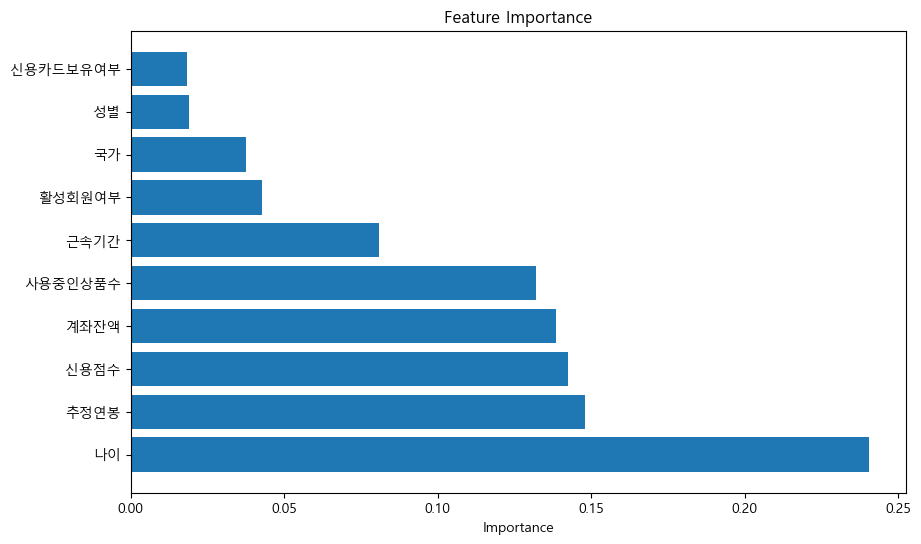

In [6]:
# 특성 중요도 계산
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
plt.title('Feature Importance')
plt.barh(range(X.shape[1]), importances[indices], align='center')
plt.yticks(range(X.shape[1]), np.array(X.columns)[indices])
plt.xlabel('Importance')
plt.show()

In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier


# 랜덤포레스트 모델 학습
rf = RandomForestClassifier(random_state=42)


# 하이퍼파라미터 그리드 정의
param_grid = {
    'n_estimators' : [100,200,300],
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [3, 4, 5, 6, 7],
    'max_features': ['auto', 'sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

# 그리드 서치 설정
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1)

# 그리드 서치 실행
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 출력
print("최적 하이퍼파라미터:", grid_search.best_params_)
print("최고 정확도:", grid_search.best_score_)

# 테스트 데이터에 대한 평가
test_accuracy = grid_search.score(X_test, y_test)
print("테스트 데이터 정확도:", test_accuracy)

In [8]:
# 결정 트리 모델 생성 (주어진 하이퍼파라미터 적용)
rf = RandomForestClassifier(criterion='gini', 
    max_depth=7, 
    max_features=None, 
    min_samples_leaf=3, 
    min_samples_split=10,
    n_estimators = 100,
    random_state=42
)
# 모델 훈련
rf.fit(X_train, y_train)

# 예측
y_pred = rf.predict(X_test)

In [9]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.865
Precision: 0.783410138248848
Recall 0.43256997455470736
f1_score 0.5573770491803278
Confusion Matrix:
 [[1560   47]
 [ 223  170]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.78      0.43      0.56       393

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.86      0.86      0.85      2000



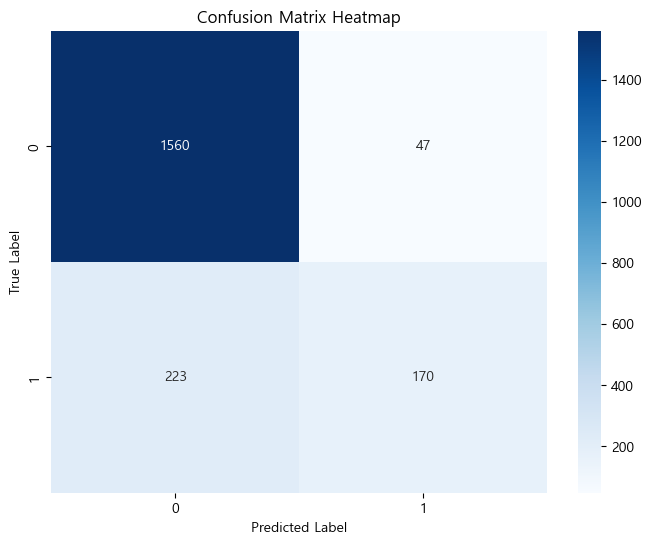

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

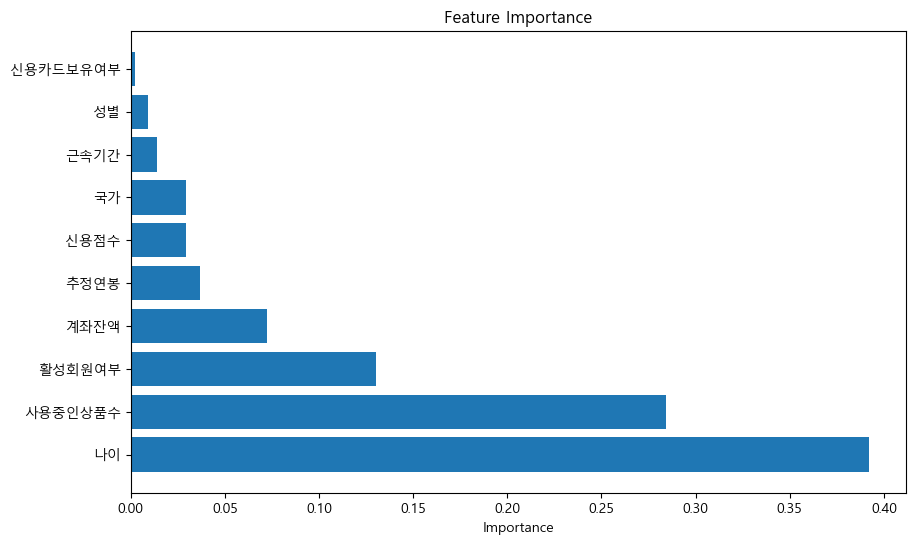

In [11]:
# 특성 중요도 계산
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
plt.title('Feature Importance')
plt.barh(range(X.shape[1]), importances[indices], align='center')
plt.yticks(range(X.shape[1]), np.array(X.columns)[indices])
plt.xlabel('Importance')
plt.show()